In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded ✅")

Libraries loaded ✅


In [3]:
url = "https://raw.githubusercontent.com/anshisharma9472-ops/hr-analytics-attrition/main/HR_Attrition.csv"

df = pd.read_csv(url)
print("Dataset loaded ✅")
print("Shape:", df.shape)

Dataset loaded ✅
Shape: (1470, 35)


In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
print(df['Attrition'].value_counts())
print("\nAttrition Rate:", round(df['Attrition'].value_counts(normalize=True)['Yes'] * 100, 2), "%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12 %


In [9]:
# Find columns with only 1 unique value
useless_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Useless columns:", useless_cols)

df = df.drop(columns=useless_cols)
print("Remaining columns:", df.shape[1])

Useless columns: ['EmployeeCount', 'Over18', 'StandardHours']
Remaining columns: 32


In [10]:
df['Attrition_num'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(df['Attrition_num'].value_counts())

Attrition_num
0    1233
1     237
Name: count, dtype: int64


/tmp/ipykernel_9279/2379263482.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Reds_r')


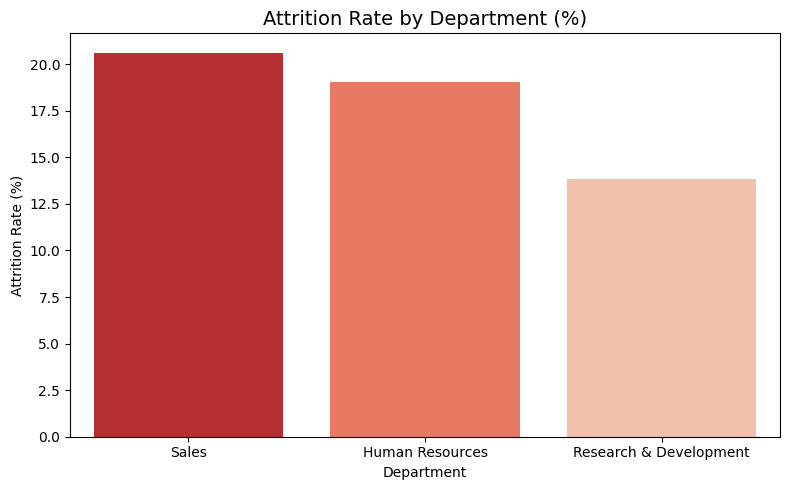

In [11]:
dept_attrition = df.groupby('Department')['Attrition_num'].mean() * 100
dept_attrition = dept_attrition.round(2).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=dept_attrition.index, y=dept_attrition.values, palette='Reds_r')
plt.title('Attrition Rate by Department (%)', fontsize=14)
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Department')
plt.tight_layout()
plt.savefig('attrition_by_department.png', dpi=150)
plt.show()

/tmp/ipykernel_9279/2026329539.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_attrition.index, y=age_attrition.values, palette='Blues_r')


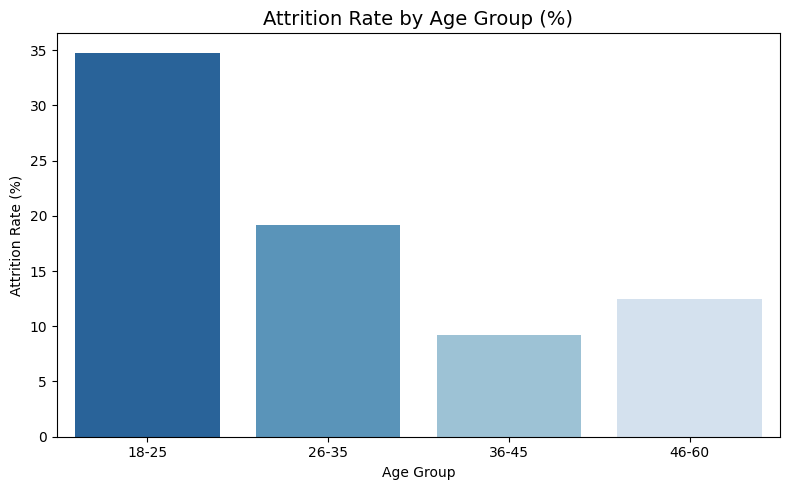

In [12]:
# Create age bins
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 60],
                         labels=['18-25', '26-35', '36-45', '46-60'])

age_attrition = df.groupby('AgeGroup', observed=True)['Attrition_num'].mean() * 100
age_attrition = age_attrition.round(2)

plt.figure(figsize=(8, 5))
sns.barplot(x=age_attrition.index, y=age_attrition.values, palette='Blues_r')
plt.title('Attrition Rate by Age Group (%)', fontsize=14)
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Age Group')
plt.tight_layout()
plt.savefig('attrition_by_age.png', dpi=150)
plt.show()

/tmp/ipykernel_9279/3925363309.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ot_attrition.index, y=ot_attrition.values, palette='Oranges_r')


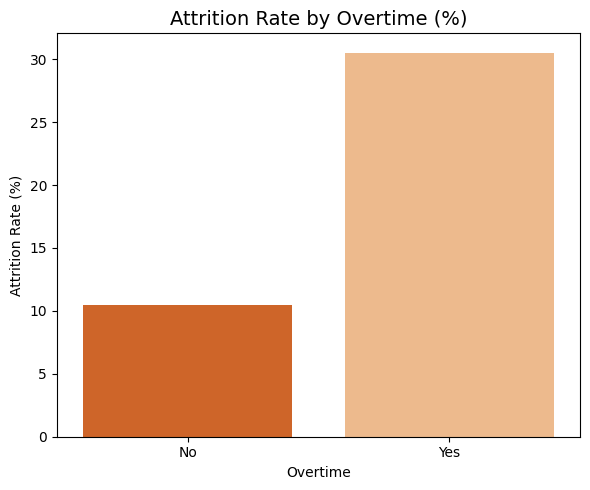

In [13]:
ot_attrition = df.groupby('OverTime')['Attrition_num'].mean() * 100
ot_attrition = ot_attrition.round(2)

plt.figure(figsize=(6, 5))
sns.barplot(x=ot_attrition.index, y=ot_attrition.values, palette='Oranges_r')
plt.title('Attrition Rate by Overtime (%)', fontsize=14)
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Overtime')
plt.tight_layout()
plt.savefig('attrition_by_overtime.png', dpi=150)
plt.show()

/tmp/ipykernel_9279/1244412773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')


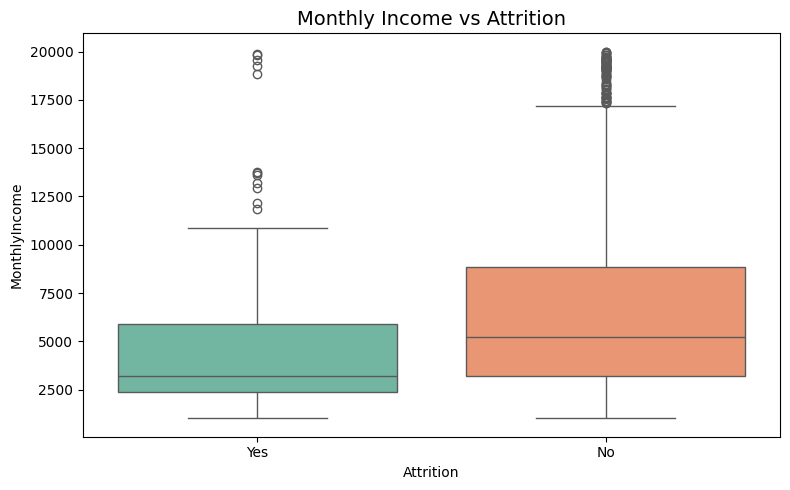

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')
plt.title('Monthly Income vs Attrition', fontsize=14)
plt.tight_layout()
plt.savefig('income_vs_attrition.png', dpi=150)
plt.show()

/tmp/ipykernel_9279/3081909037.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=js_attrition.index, y=js_attrition.values, palette='Purples_r')


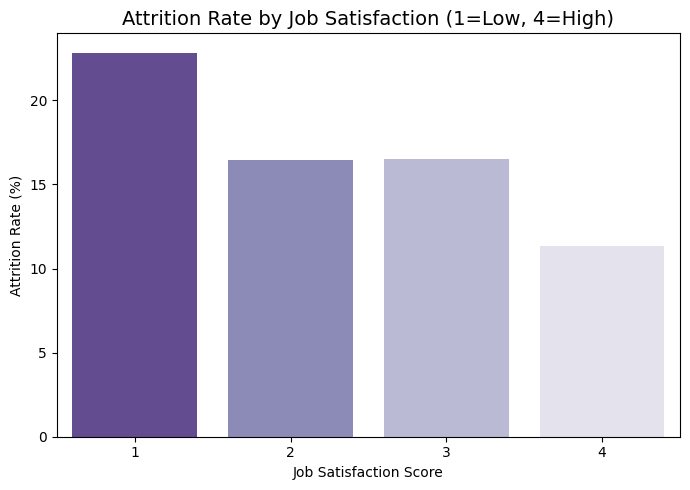

In [15]:
js_attrition = df.groupby('JobSatisfaction')['Attrition_num'].mean() * 100
js_attrition = js_attrition.round(2)

plt.figure(figsize=(7, 5))
sns.barplot(x=js_attrition.index, y=js_attrition.values, palette='Purples_r')
plt.title('Attrition Rate by Job Satisfaction (1=Low, 4=High)', fontsize=14)
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Job Satisfaction Score')
plt.tight_layout()
plt.savefig('attrition_by_satisfaction.png', dpi=150)
plt.show()

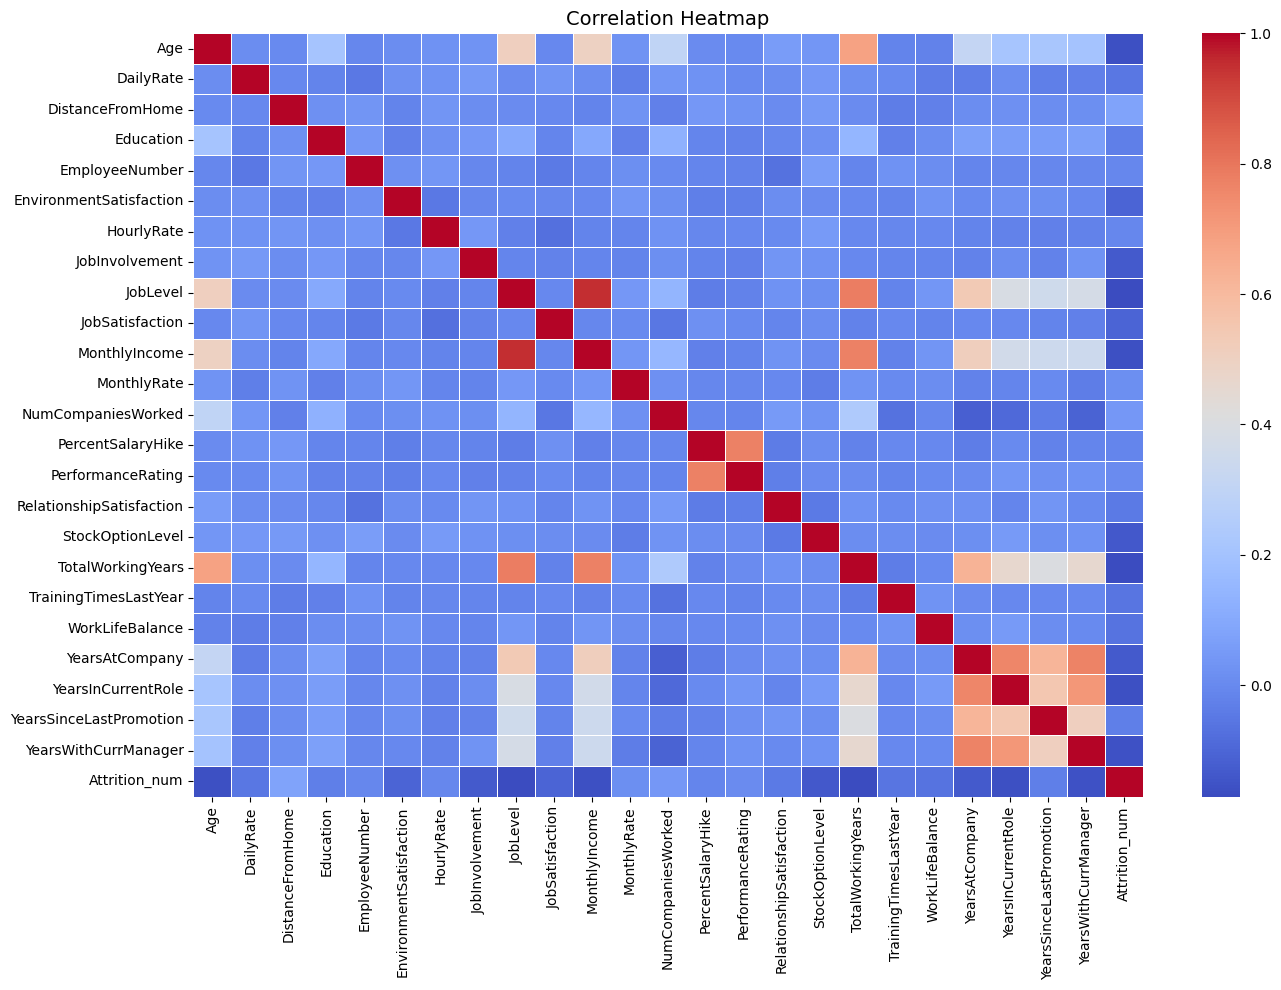

In [16]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [17]:
df.to_csv('hr_attrition_cleaned.csv', index=False)
print("Cleaned dataset saved ✅")

Cleaned dataset saved ✅


In [18]:
df = pd.read_csv('hr_attrition_cleaned.csv')
print("Cleaned data loaded ✅")
print("Shape:", df.shape)

Cleaned data loaded ✅
Shape: (1470, 34)


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score)

print("ML libraries loaded ✅")

ML libraries loaded ✅


In [20]:
df_model = df.copy()

# Drop columns not useful for modelling
df_model = df_model.drop(columns=['Attrition', 'EmployeeNumber'])

# Encode all object (text) columns
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

print("Encoding done ✅")
print("Shape:", df_model.shape)

Encoding done ✅
Shape: (1470, 32)


In [21]:
X = df_model.drop(columns=['Attrition_num'])
y = df_model['Attrition_num']

print("Features:", X.shape[1])
print("Target distribution:\n", y.value_counts())

Features: 31
Target distribution:
 Attrition_num
0    1233
1     237
Name: count, dtype: int64


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1176
Test size: 294


In [23]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


In [24]:
y_pred = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 84.01 %
ROC-AUC Score: 0.543

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.11      0.18        47

    accuracy                           0.84       294
   macro avg       0.68      0.54      0.54       294
weighted avg       0.80      0.84      0.79       294



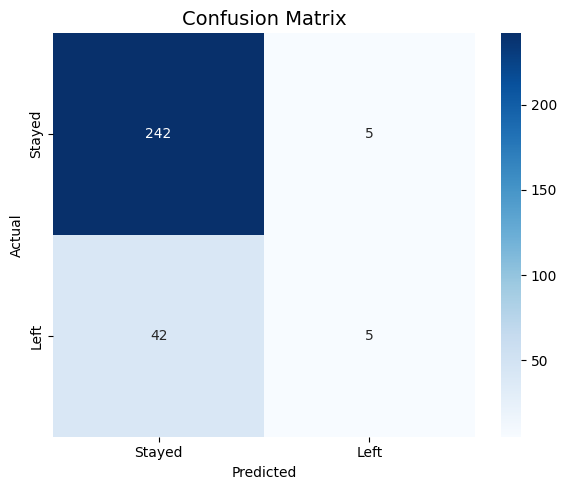

In [25]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

/tmp/ipykernel_9279/489310001.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


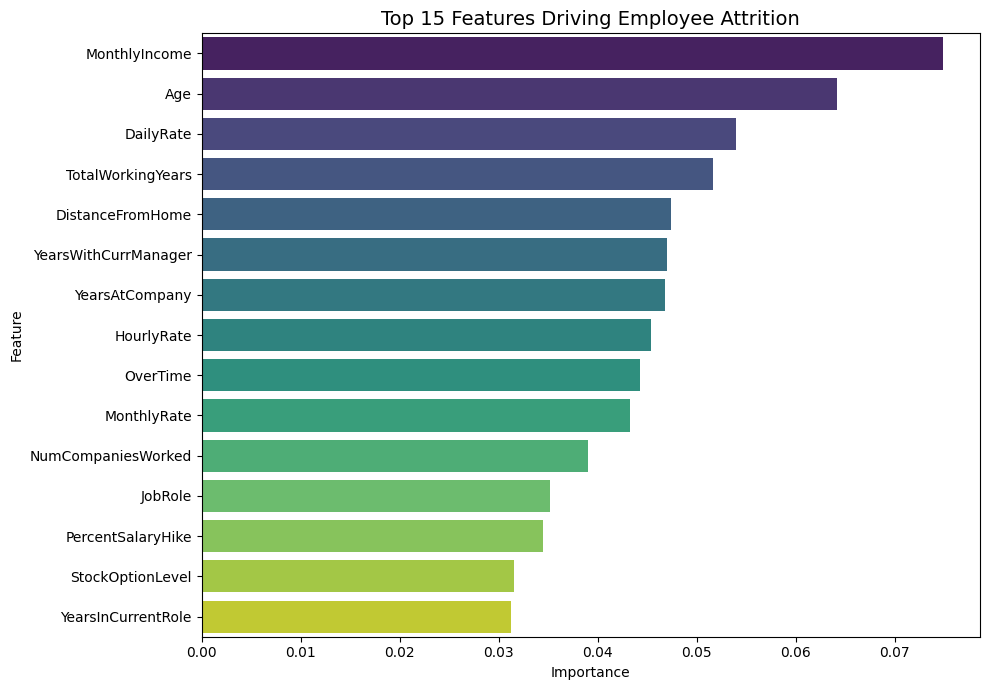

In [26]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Top 15 Features Driving Employee Attrition', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [27]:
results_df = X_test.copy()
results_df['Actual_Attrition'] = y_test.values
results_df['Predicted_Attrition'] = y_pred
results_df['Attrition_Probability'] = rf_model.predict_proba(X_test)[:, 1].round(3)

results_df.to_csv('hr_model_predictions.csv', index=False)
print("Predictions saved ✅")

Predictions saved ✅


In [28]:
import sqlite3
import sqlalchemy
from sqlalchemy import create_engine

print("SQL libraries loaded ✅")

SQL libraries loaded ✅


In [29]:
# Create database engine
engine = create_engine('sqlite:///hr_analytics.db')

# Load cleaned dataframe into SQL table
df.to_sql('employees', con=engine, if_exists='replace', index=False)

print("Data loaded into SQLite ✅")
print("Table: employees")

# Verify
with engine.connect() as conn:
    result = conn.execute(sqlalchemy.text("SELECT COUNT(*) FROM employees"))
    print("Total rows:", result.fetchone()[0])

Data loaded into SQLite ✅
Table: employees
Total rows: 1470


In [30]:
def run_query(sql):
    with engine.connect() as conn:
        return pd.read_sql(sqlalchemy.text(sql), conn)

In [31]:
q1 = """
SELECT
    COUNT(*) AS total_employees,
    SUM(Attrition_num) AS employees_left,
    ROUND(SUM(Attrition_num) * 100.0 / COUNT(*), 2) AS attrition_rate_pct
FROM employees
"""
run_query(q1)

,total_employees,employees_left,attrition_rate_pct
0,1470,237,16.12


In [32]:
q2 = """
SELECT
    Department,
    COUNT(*) AS total,
    SUM(Attrition_num) AS left_count,
    ROUND(SUM(Attrition_num) * 100.0 / COUNT(*), 2) AS attrition_pct
FROM employees
GROUP BY Department
ORDER BY attrition_pct DESC
"""
run_query(q2)

,Department,total,left_count,attrition_pct
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84


In [33]:
q3 = """
SELECT
    JobRole,
    COUNT(*) AS total,
    SUM(Attrition_num) AS left_count,
    ROUND(SUM(Attrition_num) * 100.0 / COUNT(*), 2) AS attrition_pct
FROM employees
GROUP BY JobRole
ORDER BY attrition_pct DESC
"""
run_query(q3)

,JobRole,total,left_count,attrition_pct
0,Sales Representative,83,33,39.76
1,Laboratory Technician,259,62,23.94
2,Human Resources,52,12,23.08
3,Sales Executive,326,57,17.48
4,Research Scientist,292,47,16.10
5,Manufacturing Director,145,10,6.90
6,Healthcare Representative,131,9,6.87
7,Manager,102,5,4.90
8,Research Director,80,2,2.50


In [34]:
q4 = """
SELECT
    Attrition,
    ROUND(AVG(MonthlyIncome), 2) AS avg_monthly_income,
    ROUND(AVG(Age), 1) AS avg_age,
    ROUND(AVG(YearsAtCompany), 1) AS avg_tenure_years
FROM employees
GROUP BY Attrition
"""
run_query(q4)

,Attrition,avg_monthly_income,avg_age,avg_tenure_years
0,No,6832.74,37.6,7.4
1,Yes,4787.09,33.6,5.1


In [35]:
q5 = """
WITH overtime_summary AS (
    SELECT
        OverTime,
        COUNT(*) AS total,
        SUM(Attrition_num) AS left_count
    FROM employees
    GROUP BY OverTime
)
SELECT
    OverTime,
    total,
    left_count,
    ROUND(left_count * 100.0 / total, 2) AS attrition_pct
FROM overtime_summary
ORDER BY attrition_pct DESC
"""
run_query(q5)

,OverTime,total,left_count,attrition_pct
0,Yes,416,127,30.53
1,No,1054,110,10.44


In [36]:
q6 = """
SELECT
    EmployeeNumber,
    Department,
    JobRole,
    MonthlyIncome,
    Age,
    YearsAtCompany,
    JobSatisfaction,
    RANK() OVER (ORDER BY MonthlyIncome ASC, JobSatisfaction ASC) AS risk_rank
FROM employees
WHERE Attrition_num = 0
ORDER BY risk_rank
LIMIT 10
"""
run_query(q6)

,EmployeeNumber,Department,JobRole,MonthlyIncome,Age,YearsAtCompany,JobSatisfaction,risk_rank
0,1012,Research & Development,Research Scientist,1051,18,0,4,1
1,1056,Sales,Sales Representative,1052,28,1,2,2
2,1974,Research & Development,Laboratory Technician,1129,31,1,4,3
3,411,Sales,Sales Representative,1200,18,0,3,4
4,1270,Research & Development,Research Scientist,1223,23,1,3,5
5,30,Research & Development,Research Scientist,1232,21,0,4,6
6,1482,Research & Development,Research Scientist,1274,30,1,3,7
7,704,Research & Development,Laboratory Technician,1281,35,1,3,8
8,201,Research & Development,Laboratory Technician,1483,19,1,2,9
9,1839,Research & Development,Research Scientist,1514,18,0,3,10


In [37]:
q7 = """
SELECT
    YearsAtCompany,
    COUNT(*) AS total,
    SUM(Attrition_num) AS left_count,
    ROUND(SUM(Attrition_num) * 100.0 / COUNT(*), 2) AS attrition_pct
FROM employees
GROUP BY YearsAtCompany
ORDER BY attrition_pct DESC
LIMIT 10
"""
run_query(q7)

,YearsAtCompany,total,left_count,attrition_pct
0,40,1,1,100.00
1,23,2,1,50.00
2,0,44,16,36.36
3,1,171,59,34.50
4,32,3,1,33.33
5,31,3,1,33.33
6,2,127,27,21.26
7,33,5,1,20.00
8,4,110,19,17.27
9,24,6,1,16.67


In [38]:
from google.colab import files

# Save each query result
run_query(q1).to_csv('sql_overall_attrition.csv', index=False)
run_query(q2).to_csv('sql_dept_attrition.csv', index=False)
run_query(q3).to_csv('sql_jobrole_attrition.csv', index=False)
run_query(q4).to_csv('sql_income_comparison.csv', index=False)
run_query(q5).to_csv('sql_overtime_attrition.csv', index=False)
run_query(q7).to_csv('sql_tenure_attrition.csv', index=False)

print("All query results saved ✅")

All query results saved ✅


In [39]:
files.download('sql_overall_attrition.csv')
files.download('sql_dept_attrition.csv')
files.download('sql_jobrole_attrition.csv')
files.download('sql_income_comparison.csv')
files.download('sql_overtime_attrition.csv')
files.download('sql_tenure_attrition.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>